# Auto dynII across neural timepoints

Compute a directed auto Information Imbalance between neural population geometries at different timepoints. The output matrix is `n_time x n_time`: the upper triangular entries are past -> future and the lower triangular entries are future -> past. The diagonal is the same-time auto dynII.

The notebook follows `static_dynII_delay_embeddings.ipynb` but removes the model-feature comparison and specializes the computation to neural-vs-neural timepoints.


In [1]:
import os, sys, yaml
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[1]

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
if ENV not in config:
    raise KeyError(f"MY_ENV={ENV!r} is not in config.yaml. Available environments: {list(config)}")

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster
from useful_stuff.general_utils.II import dynInformationImbalance
from useful_stuff.general_utils.utils import TimeSeries, print_wise


## Parameters

Set `use_delay_embedding=True` to replace each neural population vector at time `t` with a flattened window around `t`. With `pad_mode=None`, only valid center timepoints are retained; with `pad_mode="edge"`, `"reflect"`, or `"constant"`, the original number of timepoints is preserved.

The matrix is directional: entry `(i, j)` is the II from the neighborhood structure at row time `i` to the rank structure at column time `j`.


In [24]:
cfg = SimpleNamespace(
    monkey_name="three0",
    date="250313",
    brain_area="AIT",
    new_fs=200,
    RDM_metric="cosine_cnt",
    k=10,
    use_delay_embedding=True,
    delay_lags=(-10, 0),
    pad_mode=None,
    use_subsamples=False,
    subsamples_size=200,
    n_iterations=10,
    random_seed=0,
    max_lag=100,
    min_lag_datapts=10,
)

print_wise(cfg)


15:57:24 - namespace(monkey_name='three0', date='250313', brain_area='AIT', new_fs=200, RDM_metric='cosine_cnt', k=10, use_delay_embedding=True, delay_lags=(-10, 0), pad_mode=None, use_subsamples=False, subsamples_size=200, n_iterations=10, random_seed=0, max_lag=100, min_lag_datapts=10)


## Delay-embedding helpers


In [25]:
def delay_embed_raster(raster: TimeSeries, lags: tuple[int, int], pad_mode: str | None = None) -> TimeSeries:
    X = raster.get_array()
    if X.ndim != 3:
        raise ValueError(f"Expected raster shape (neurons, time, images/trials), got {X.shape}")

    embedded_trials = []
    for image_idx in range(X.shape[2]):
        image_ts = TimeSeries(X[:, :, image_idx], raster.get_fs())
        embedded_trials.append(image_ts.delay_embeddings(lags, pad_mode=pad_mode).get_array())

    embedded = np.stack(embedded_trials, axis=2)
    return TimeSeries(embedded, raster.get_fs())


def delay_embedding_label(lags: tuple[int, int], pad_mode: str | None) -> str:
    pad = "valid" if pad_mode is None else pad_mode
    return f"delayemb_lags{lags[0]}to{lags[1]}_{pad}"


def time_axis_for_raster(raster: TimeSeries, use_delay_embedding: bool, lags: tuple[int, int], pad_mode: str | None):
    n_raw_time = raster.get_array().shape[1]
    fs = raster.get_fs()
    if not use_delay_embedding or pad_mode is not None:
        return np.arange(n_raw_time) / fs

    lag_start, lag_end = lags
    valid_indices = np.arange(-lag_start, n_raw_time - lag_end)
    return valid_indices / fs


## Load data and optionally create temporal embeddings


In [26]:
area_rasters = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

print_wise(f"raw raster shape: {area_rasters.get_array().shape}, fs={area_rasters.get_fs()} Hz")

if cfg.use_delay_embedding:
    analysis_rasters = delay_embed_raster(
        area_rasters,
        lags=cfg.delay_lags,
        pad_mode=cfg.pad_mode,
    )
    analysis_label = delay_embedding_label(cfg.delay_lags, cfg.pad_mode)
else:
    analysis_rasters = area_rasters
    analysis_label = "raw"

time_s = time_axis_for_raster(area_rasters, cfg.use_delay_embedding, cfg.delay_lags, cfg.pad_mode)
if len(time_s) != analysis_rasters.get_array().shape[1]:
    raise ValueError(f"time axis length {len(time_s)} does not match raster time length {analysis_rasters.get_array().shape[1]}")

print_wise(f"analysis raster shape: {analysis_rasters.get_array().shape}, label={analysis_label}")


15:57:28 - raw raster shape: (25, 60, 776), fs=200 Hz
15:57:28 - analysis raster shape: (275, 50, 776), label=delayemb_lags-10to0_valid


## Auto dynII computation

`past_to_future_matrix[i, j]` is the II from time `i` to time `j`. Therefore, if `i < j`, it is past -> future; if `i > j`, it is future -> past. `future_to_past_matrix` is kept as a cross-check from the reverse dynII call.


In [27]:
def compute_auto_dynII_single(raster: TimeSeries, metric: str, k: int):
    auto_ii = dynInformationImbalance(metric, metric, k=k)
    auto_ii.compute_RDM_timeseries(raster, "signal")

    # Use the same neural RDM/rank time series as both sides of the directed comparison.
    auto_ii.set_RDM_timeseries(auto_ii.get_RDM_timeseries("signal"), "model")
    auto_ii.compute_distance_ranks_timeseries("signal")
    auto_ii.model_distance_ranks_timeseries = auto_ii.signal_distance_ranks_timeseries
    auto_ii.model_kmins_idx_timeseries = auto_ii.signal_kmins_idx_timeseries

    past_to_future_matrix, future_to_past_matrix = auto_ii.compute_both_dynII()

    triangular = np.empty_like(past_to_future_matrix)
    diag_idx = np.diag_indices_from(triangular)
    upper_idx = np.triu_indices_from(triangular, k=1)
    lower_idx = np.tril_indices_from(triangular, k=-1)

    triangular[diag_idx] = past_to_future_matrix[diag_idx]
    triangular[upper_idx] = past_to_future_matrix[upper_idx]
    triangular[lower_idx] = future_to_past_matrix.T[lower_idx]

    return {
        "auto_ii": auto_ii,
        "past_to_future_matrix": past_to_future_matrix,
        "future_to_past_matrix": future_to_past_matrix,
        "auto_dynii_triangular": triangular,
    }


def compute_auto_dynII(raster: TimeSeries, cfg):
    raster_array = raster.get_array()
    n_trials = raster_array.shape[2]

    if not cfg.use_subsamples:
        result = compute_auto_dynII_single(raster, cfg.RDM_metric, cfg.k)
        result["auto_dynii_triangular_mean"] = result["auto_dynii_triangular"]
        result["auto_dynii_triangular_std"] = None
        return result

    if cfg.subsamples_size > n_trials:
        raise ValueError(f"subsamples_size={cfg.subsamples_size} exceeds available trials/images ({n_trials})")
    if cfg.n_iterations < 1:
        raise ValueError("n_iterations must be >= 1")

    rng = np.random.default_rng(cfg.random_seed)
    triangular_iterations = []
    past_to_future_iterations = []
    future_to_past_iterations = []

    for iteration in range(cfg.n_iterations):
        subset = rng.choice(n_trials, size=cfg.subsamples_size, replace=False)
        subset_raster = TimeSeries(raster_array[:, :, subset], raster.get_fs())
        iteration_result = compute_auto_dynII_single(subset_raster, cfg.RDM_metric, cfg.k)
        triangular_iterations.append(iteration_result["auto_dynii_triangular"])
        past_to_future_iterations.append(iteration_result["past_to_future_matrix"])
        future_to_past_iterations.append(iteration_result["future_to_past_matrix"])
        print_wise(f"completed subsample {iteration + 1}/{cfg.n_iterations}")

    triangular_iterations = np.stack(triangular_iterations, axis=0)
    past_to_future_iterations = np.stack(past_to_future_iterations, axis=0)
    future_to_past_iterations = np.stack(future_to_past_iterations, axis=0)

    return {
        "auto_ii": None,
        "auto_dynii_triangular": triangular_iterations.mean(axis=0),
        "auto_dynii_triangular_mean": triangular_iterations.mean(axis=0),
        "auto_dynii_triangular_std": triangular_iterations.std(axis=0),
        "auto_dynii_triangular_iterations": triangular_iterations,
        "past_to_future_matrix": past_to_future_iterations.mean(axis=0),
        "future_to_past_matrix": future_to_past_iterations.mean(axis=0),
        "past_to_future_iterations": past_to_future_iterations,
        "future_to_past_iterations": future_to_past_iterations,
    }


In [28]:
auto_dynii_results = compute_auto_dynII(analysis_rasters, cfg)

auto_dynii_triangular = auto_dynii_results["auto_dynii_triangular"]
past_to_future_matrix = auto_dynii_results["past_to_future_matrix"]
future_to_past_matrix = auto_dynii_results["future_to_past_matrix"]

print_wise(f"auto dynII matrix shape: {auto_dynii_triangular.shape}")
print_wise(f"same-time mean dynII: {np.diag(auto_dynii_triangular).mean():.4f}")


15:57:30 - auto dynII matrix shape: (50, 50)
15:57:30 - same-time mean dynII: 0.0116


## Lag plot helpers

For each positive lag, `past_to_future` averages the upper diagonal at `+lag`, and `future_to_past` averages the lower diagonal at `-lag`.


In [29]:
def directional_lagplot(auto_dynii_matrix, max_lag, min_datapts=10, summary_stat=np.mean):
    n_time = auto_dynii_matrix.shape[0]
    if auto_dynii_matrix.shape[0] != auto_dynii_matrix.shape[1]:
        raise ValueError(f"Expected a square matrix, got {auto_dynii_matrix.shape}")

    max_lag = min(max_lag, n_time - min_datapts)
    if max_lag < 1:
        raise ValueError("max_lag is too small after enforcing min_datapts")

    lag_steps = np.arange(0, max_lag + 1)
    past_to_future = np.empty(max_lag + 1, dtype=float)
    future_to_past = np.empty(max_lag + 1, dtype=float)

    same_time = np.diag(auto_dynii_matrix)
    past_to_future[0] = summary_stat(same_time)
    future_to_past[0] = summary_stat(same_time)

    for lag in range(1, max_lag + 1):
        past_to_future[lag] = summary_stat(np.diag(auto_dynii_matrix, k=lag))
        future_to_past[lag] = summary_stat(np.diag(auto_dynii_matrix, k=-lag))

    return lag_steps, past_to_future, future_to_past


lag_steps, past_to_future_lag, future_to_past_lag = directional_lagplot(
    auto_dynii_triangular,
    max_lag=cfg.max_lag,
    min_datapts=cfg.min_lag_datapts,
)
lag_s = lag_steps / analysis_rasters.get_fs()


## Plot matrix and lag plot


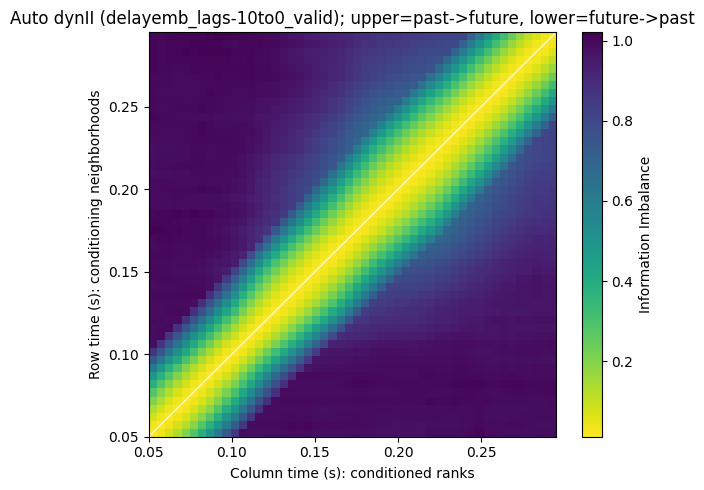

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    auto_dynii_triangular,
    origin="lower",
    aspect="auto",
    extent=[time_s[0], time_s[-1], time_s[0], time_s[-1]],
    cmap="viridis_r",
)
ax.plot([time_s[0], time_s[-1]], [time_s[0], time_s[-1]], color="white", linewidth=1, alpha=0.8)
ax.set_xlabel("Column time (s): conditioned ranks")
ax.set_ylabel("Row time (s): conditioning neighborhoods")
ax.set_title(f"Auto dynII ({analysis_label}); upper=past->future, lower=future->past")
fig.colorbar(im, ax=ax, label="Information Imbalance")
plt.tight_layout()


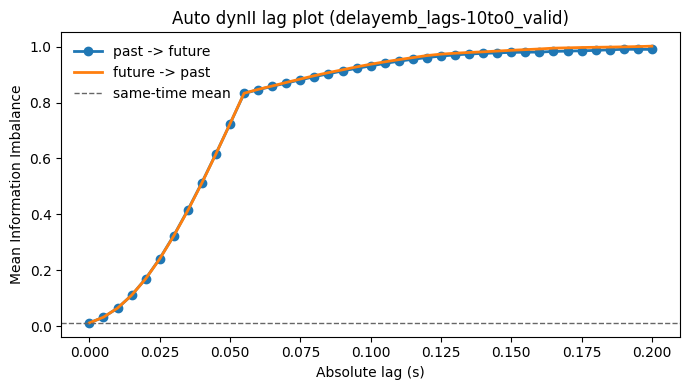

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lag_s, past_to_future_lag, label="past -> future", linewidth=2, marker="o")
ax.plot(lag_s, future_to_past_lag, label="future -> past", linewidth=2)
ax.axhline(np.diag(auto_dynii_triangular).mean(), color="0.4", linestyle="--", linewidth=1, label="same-time mean")
ax.set_xlabel("Absolute lag (s)")
ax.set_ylabel("Mean Information Imbalance")
ax.set_title(f"Auto dynII lag plot ({analysis_label})")
ax.legend(frameon=False)
plt.tight_layout()


## Optional diagnostics


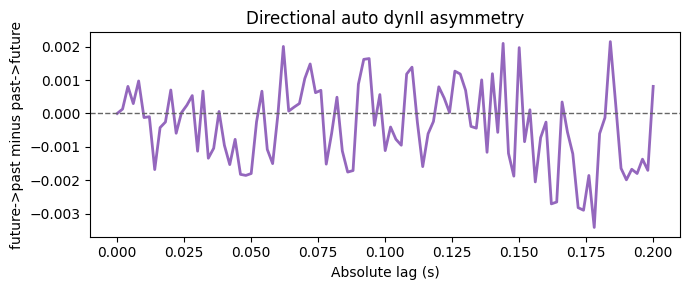

In [10]:
directional_asymmetry = future_to_past_lag - past_to_future_lag

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(lag_s, directional_asymmetry, color="tab:purple", linewidth=2)
ax.axhline(0, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("Absolute lag (s)")
ax.set_ylabel("future->past minus past->future")
ax.set_title("Directional auto dynII asymmetry")
plt.tight_layout()
